In [8]:
# importing libraries
import math
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from graphviz import Digraph

In [148]:
class Engine:
    def __init__(self,data,children = (),_op='',label=''):
        self.data = data
        self.prev = set(children)
        self.label = label
        self._op = _op
        self._backward = lambda : None
        self.grad = 0.0
    def __repr__(self):
        return f"(value={self.data})"
    def __add__(self, other):
        out = Engine(self.data + other.data,(self,other),'+' )
        def _backward():
            self.grad += out.grad
            other.grad += out.grad 
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Engine(self.data*other.data, (self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def backward(self):

        self.grad = 1

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v.prev:
                    build_topo(child)

                topo.append(v)

        build_topo(self)

        for node in reversed(topo):
            node._backward()



In [149]:
x1 = Engine(2.0); x1.label = 'x1'
x2 = Engine(3.0); x2.label = 'x2'
w1 = Engine(1.0); w1.label = 'w1'
w2 = Engine(0.0); w2.label = 'w2'
b = Engine(6.887877787); b.label = 'b'

In [150]:
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
val = x1w1x2w2 + b; val.label = 'out'
print(x1w1.prev)
print(x2w2.prev)
print(val.prev)

{(value=1.0), (value=2.0)}
{(value=3.0), (value=0.0)}
{(value=6.887877787), (value=2.0)}


In [151]:
## Visualizing the graph

def createNodesEdges(val):
    nodes, edges = set() , set()
    def build(data):
        if data not in nodes:
            nodes.add(data)
            for adj in data.prev:
                edges.add((adj, data))
                build(adj)
    build(val)
    return nodes, edges

def drawgraph(someValue):
    dot = Digraph(format="svg")
    dot.attr(rankdir="LR")  
    nodes , edges = createNodesEdges(someValue)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{<out> %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    
    return dot

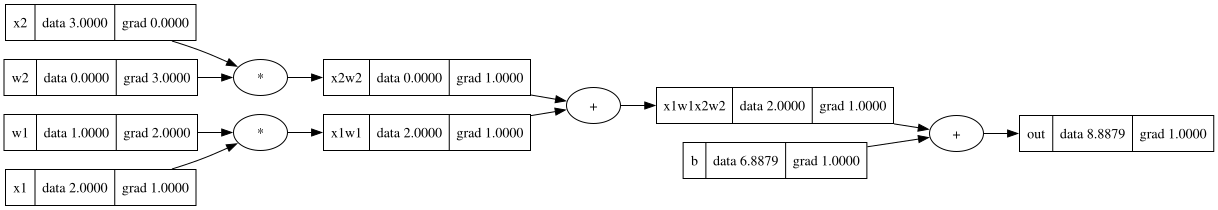

In [154]:
drawgraph(val)

In [153]:
val.backward()